In [1]:
from datetime import datetime
import pickle
import os
from multiprocessing import Pool

import numpy as np
import pandas as pd
import lingam
from scipy.stats import kendalltau

import matplotlib.pyplot as plt

np.random.seed(0)

## 参考用テストデータ

(10000, 6)
[-0.00584224 -0.00252382 -0.01020229 -0.00682629 -0.00850247 -0.011125  ]
[1.00819616 1.01717783 1.00812647 1.00746063 1.00102207 0.99683643]


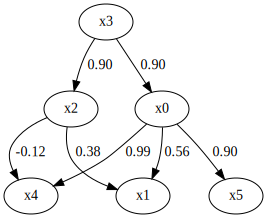

In [15]:
m = np.array([
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.565,  0.000,  0.377,  0.000,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.000,  0.000,  0.000],
    [ 0.991,  0.000, -0.124,  0.000,  0.000,  0.000],
    [ 0.895,  0.000,  0.000,  0.000,  0.000,  0.000]
])

sample_size = 10000

error_vars = [0.2, 0.2, 0.2, 1.0, 0.2, 0.2]
params = [0.5 * np.sqrt(12 * v) for v in error_vars]

generate_error = lambda p: np.random.uniform(-p, p, size=sample_size)
e = np.array([generate_error(p) for p in params])

X = np.linalg.pinv(np.eye(len(m)) - m) @ e
X = X.T

print(X.shape)

# 平均ゼロは前提
print(X.mean(axis=0))
print(X.var(axis=0))

lingam.utils.make_dot(m)

[3, 0, 2, 1, 5, 4]


,0,1,2,3,4,5
0,0.000000,0.0,0.000000,0.894416,0.0,0.00000
1,0.581984,0.0,0.365315,0.000000,0.0,0.00000
2,0.000000,0.0,0.000000,0.897030,0.0,0.00000
3,0.000000,0.0,0.000000,0.000000,0.0,0.00000
4,0.977232,0.0,-0.121830,0.000000,0.0,0.01197
5,0.890714,0.0,0.000000,0.000000,0.0,0.00000


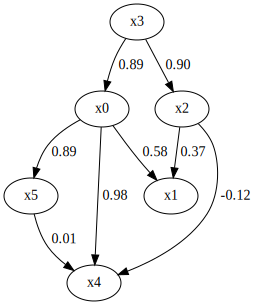

In [17]:
model = lingam.HighDimDirectLiNGAM()
model.fit(X)
print(model.causal_order_)

display(pd.DataFrame(model.adjacency_matrix_))
lingam.utils.make_dot(model.adjacency_matrix_)

[3, 0, 2, 4, 5, 1]


,0,1,2,3,4,5
0,0.000000,0.0,0.000000,0.894416,0.0,0.0
1,0.581984,0.0,0.365315,0.000000,0.0,0.0
2,0.000000,0.0,0.000000,0.897030,0.0,0.0
3,0.000000,0.0,0.000000,0.000000,0.0,0.0
4,0.987866,0.0,-0.121795,0.000000,0.0,0.0
5,0.890714,0.0,0.000000,0.000000,0.0,0.0


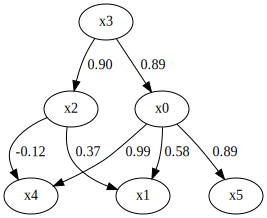

In [18]:
model = lingam.DirectLiNGAM()
model.fit(X)
print(model.causal_order_)

display(pd.DataFrame(model.adjacency_matrix_))
lingam.utils.make_dot(model.adjacency_matrix_)

並びは違うがどちらもあっているので、大丈夫そう。

## Low dimensional consistency

In [7]:
def make_dag_and_errors(n_nodes, sample_size, J=3):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(0.5, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        pa = np.random.choice(candidates, size=num_pa)

        # the corresponding edge weights are set to +-1/5
        dag[v, pa] = np.random.uniform(-1/5, 1/5, size=len(pa))

    # The n error terms for variable v are generated by selecting σv ∼ unif(.8, 1)
    # drawing εvi ∼ σvunif(−√3,√3).
    errors = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    errors = errors * np.random.uniform(0.8, 1, size=n_nodes)

    return dag, errors

## テスト

対角の下に必ず値があるので順位は一意に定まる。

ループ5回で30秒。100倍ならば1時間弱かかるだろう。

In [11]:

# 最終的な正式実験用
def run_test(p_list=None, n_list_func=None, loop_num=500, make_func=None, disable_direct=False):

    test_start = datetime.now()

    results = {}

    if p_list is None:
        p_list = np.arange(5, 25, 5, dtype=int)

    if n_list_func is None:
        n_list_func = lambda p: [10 * p, 50 * p]

    if make_func is None:
        make_func = make_dag_and_errors

    for p in p_list:
        true_order = np.arange(p)

        for n in n_list_func(p):
            print(f"p={p:2d}, n={n:2d}")

            evals_high_d = []
            evals_normal = []
            elapses_high_d = []
            
            loop_start = datetime.now()

            for i in range(loop_num):
                print(f"\r{i:3d} / {loop_num}", end="")

                dag, errors = make_func(p, n)
                #display(pd.DataFrame(dag))

                X = (np.linalg.pinv(np.eye(p) - dag) @ errors.T).T

                high_d_model = lingam.HighDimDirectLiNGAM()
                #high_d_model = lingam.DirectLiNGAM(enable_high_dim=True)
                high_d_model.fit(X)

                high_d_start = datetime.now()

                eval_high_d = kendalltau(high_d_model.causal_order_, true_order).statistic
                #print(f"\n{eval_high_d:.3f}", high_d_model.causal_order_)
                evals_high_d.append(eval_high_d)

                elapse = (datetime.now() - high_d_start).total_seconds()
                elapses_high_d.append(elapse)

                if disable_direct:
                    eval_normal = None
                else:
                    normal_model = lingam.DirectLiNGAM()
                    normal_model.fit(X)
                    
                    eval_normal = kendalltau(normal_model.causal_order_, true_order).statistic
                evals_normal.append(eval_normal)

            print("\rcomplete: {:10.2f}s".format((datetime.now() - loop_start).total_seconds()))

            results[(n, p)] = {
                "high_d": evals_high_d,
                "normal": evals_normal,
                "elapse_high_d": elapses_high_d,
            }

    total_seconds = (datetime.now() - test_start).total_seconds()
    print("total time {}s".format(total_seconds))

    max_p = max(p_list)
    max_n = max(n_list_func(max_p))
    fname = datetime.now().strftime('%Y%m%d%H%M%S') + f"_{max_p}_{max_n}_{loop_num}.bin"

    with open(fname, "wb") as f:
        pickle.dump(results, f)

    print(f"\nThe result has been saved as {fname}.")

    return results

if True:
    results = run_test(loop_num=10)
else:
    # 3000sec
    with open("20240607111046_20_1000_500.bin", "rb") as f:
        results = pickle.load(f)

p= 5, n=50
complete:       0.57s
p= 5, n=250
complete:       0.52s
p=10, n=100
complete:       2.44s
p=10, n=500
complete:       2.81s
p=15, n=150
complete:       7.55s
p=15, n=750
complete:       9.17s
p=20, n=200
complete:      15.86s
p=20, n=1000
complete:      26.10s
total time 65.033966s

The result has been saved as 20240614143202_20_1000_10.bin.


(50, 5) [0.9999999999999999, 0.39999999999999997, 0.9999999999999999, 0.9999999999999999, 0.7999999999999999, 0.9999999999999999, 0.39999999999999997, -0.19999999999999998, 0.6, 0.6]
(250, 5) [0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.6, 0.9999999999999999, 0.9999999999999999]
(100, 10) [0.7333333333333333, 0.911111111111111, 0.9999999999999999, 0.9999999999999999, 0.28888888888888886, 0.9999999999999999, 0.9555555555555554, 0.7333333333333333, 0.28888888888888886, 0.8222222222222221]
(500, 10) [0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999]
(150, 15) [1.0, 1.0, 1.0, 0.961904761904762, 1.0, 0.7333333333333334, 1.0, 0.7714285714285715, 0.7523809523809525, 1.0]
(750, 15) [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
(200, 20) [1.0, 1.

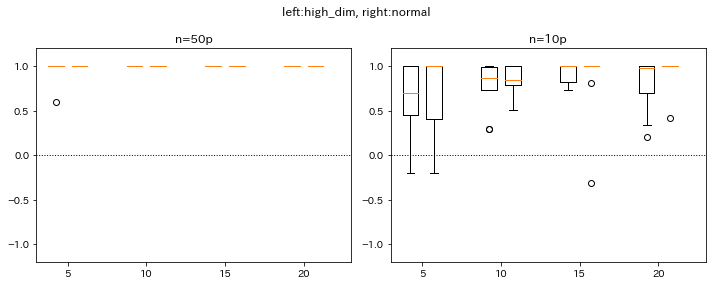

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    print((n, p), evals["high_d"])
    ax.boxplot(
        evals["high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    ax.boxplot(
        evals["normal"],
        positions=[p + 0.75],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_ylim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()

## High dimensional consistency

対角成分下の部分はエッジありで、その他はノード0,1,2をハブとするエッジだけになるみたい。

誤差がガンマ分布やガウシアンの時の実験も要るのだろうか？

In [13]:
def make_dag_and_errors2(n_nodes, sample_size, J=2):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # We first consider random DAGs and data generated as before, but with J = 2
    # 先ほどと同じ。Jの値と係数の値の範囲が違う。
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(0.65, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        pa = np.random.choice(candidates, size=num_pa)

        # the corresponding edge weights are set to +-1/5
        dag[v, pa] = np.random.uniform(-1/5, 1/5, size=len(pa))
    #display(pd.DataFrame(dag))

    # add hubs
    # 非hubノードはいずれかのハブからのエッジを受けること。対角直下は決まっているので手をださないこと。
    for v in np.arange(3, n_nodes):
        # ハブの選択と係数の作成
        coefs = np.zeros(3)
        
        if v == 3:
            # 変数3のみ特別処理。変数2との接続は強制なのでそれ以外から選ぶ。
            index = np.random.choice([0, 1])
        else:
            index = np.random.choice([0, 1, 2])
            
        coefs[index] = np.random.uniform(-1/5, 1/5)

        # すでに係数が設定してあれば、そちらを優先する。coefはdag側が0である部分のみ非ゼロになる。
        filter_ = ~np.isclose(dag[v, :3], 0)
        coefs[filter_] = 0
        
        # フィルタしているので足して設定する
        dag[v, :3] += coefs

    # disturbances
    errors = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    errors = errors * np.random.uniform(0.8, 1, size=n_nodes)

    return dag, errors

if True:
    dag, errors = make_dag_and_errors2(10, 100)
    display(pd.DataFrame(dag))
    
    # チェック
    for i in range(1000):
        dag, errors = make_dag_and_errors2(10, 10)
        # 対角から上は全部0
        assert (np.triu(dag) == 0).sum(axis=None) == 100
        # 1を超えるものは存在しない
        assert (np.abs(dag) > 1).sum() == 0
        # 非ハブは最低一つのハブを親に持つ。
        assert all((~np.isclose(dag[3:, :3], 0)).sum(axis=1) > 0)

,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
1,-0.848045,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
2,0.000000,0.910232,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
3,0.000000,0.190671,-0.900718,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
4,0.000000,-0.069903,0.030908,-0.944363,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
5,0.000000,0.000000,0.169421,0.000000,0.680615,0.00000,0.000000,0.000000,0.00000,0.0
6,0.030687,0.000000,0.000000,0.000000,0.000000,-0.93247,0.000000,0.000000,0.00000,0.0
7,0.000000,0.000000,-0.197636,0.000000,0.158039,0.00000,0.770199,0.000000,0.00000,0.0
8,0.000000,0.000000,-0.163242,0.000000,0.000000,0.00000,0.000000,-0.708448,0.00000,0.0
9,0.030733,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.77028,0.0


DirectLiNGAM抜きで、p=100だと100sec。p=200だと780秒。13分。
係数を求めるのをやめると？P=100で88秒。p=200だと746秒。

In [14]:
p_list = [25, 50, 75, 100, 125, 150, 200]

# ノード数よりもサンプル数が小さくなってしまってLassoLarsICが動かないみたい。
n_list_func = lambda p: [int((3 / 4) * p)]
#n_list_func = lambda p: [p + 1]

results = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=1, make_func=make_dag_and_errors2, disable_direct=True)

p=25, n=18
complete:       1.66s
p=50, n=37
complete:      13.24s
p=75, n=56
complete:      43.74s
p=100, n=75
  0 / 1

KeyboardInterrupt: 

In [ ]:
x = [{1:2, 3:4}, {5:6, 7:8}]
y = {}
for x_ in x:
    y.update(x_)
y